# Bidirectional error-reparameterised Predictive Coding (bePC)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/bepc.ipynb)

This notebook demonstrates **bePC**, which combines the bidirectional PC architecture ([Oliviers et al., 2025](https://arxiv.org/abs/2505.23415)) with the error reparameterisation of [ePC](https://arxiv.org/abs/2505.20137) ([Goemaere et al., 2025](https://arxiv.org/abs/2505.20137)). Concretely, we use a top-down (generative) and bottom-up (discriminative) network as in bPC, but the inference variables are the forward prediction errors $\{\epsilon_\ell\}$ (as in ePC) rather than the activities. Activities are recovered on-the-fly through an error-perturbed forward pass $\tilde{z}_\ell = f_\ell(\tilde{z}_{\ell-1}) + \epsilon_\ell$, and the bPC backward energy $\|\tilde{z}_\ell - g_{\ell+1}(\tilde{z}_{\ell+1})\|^2$ is evaluated on those perturbed activities.

The total energy is
$$
\mathcal{F} = \alpha_f \Big[ \sum_{\ell=1}^{L-1} \tfrac{1}{2}\|\epsilon_\ell\|^2 + \tfrac{1}{2}\|\mathbf{y} - \tilde{f}(\mathbf{x}, \epsilon)\|^2 \Big] + \alpha_b \sum_{\ell=0}^{L-1} \tfrac{1}{2}\|\tilde{\mathbf{z}}_\ell - g_{\ell+1}(\tilde{\mathbf{z}}_{\ell+1})\|^2.
$$

We train on MNIST in the same setup as [`bidirectional_pc.ipynb`](./bidirectional_pc.ipynb): a joint generator/classifier where $x$ is the one-hot label and $y$ is the image.

In [ ]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install matplotlib==3.0.0

In [1]:
import jpc

import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')  # ignore warnings

## Hyperparameters

In [2]:
SEED = 0

INPUT_DIM = 10
WIDTH = 256
DEPTH = 2
OUTPUT_DIM = 784
ACT_FN = "relu"

ERROR_LR = 5e-1
PARAM_LR = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 50
N_TRAIN_ITERS = 300

## Dataset

Some utils to fetch MNIST.

In [3]:
def get_mnist_loaders(batch_size):
    train_data = MNIST(train=True, normalise=True)
    test_data = MNIST(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=(0.1307), std=(0.3081)
                    )
                ]
            )
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        img = torch.flatten(img)
        label = one_hot(label)
        return img, label


def one_hot(labels, n_classes=10):
    arr = torch.eye(n_classes)
    return arr[labels]


def plot_mnist_imgs(imgs, labels, n_imgs=10):
    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imgs[i].reshape(28, 28), cmap=plt.cm.binary_r)
        plt.xlabel(jnp.argmax(labels, axis=1)[i])
    plt.show()

## Train and test

Inference updates the errors via `jpc.update_bepc_errors` (bePC energy gradient w.r.t. errors), and parameters are updated once per batch via `jpc.update_bepc_params`. Errors are reset to zero at the start of each batch with `jpc.init_epc_errors`.

In [4]:
def evaluate(generator, amortiser, test_loader):
    amort_accs = 0.
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_accs += jpc.compute_accuracy(label_batch, preds)

    img_preds = jpc.init_activities_with_ffwd(
        model=generator,
        input=label_batch
    )[-1]

    return (
        amort_accs / len(test_loader),
        label_batch,
        img_preds
    )


def train(
      seed,
      input_dim,
      width,
      depth,
      output_dim,
      act_fn,
      batch_size,
      error_lr,
      param_lr,
      test_every,
      n_train_iters,
      forward_energy_weight=1.0
):
    key = jax.random.PRNGKey(seed)
    gen_key, amort_key = jax.random.split(key, 2)

    # models (NOTE: input and output are inverted for the amortiser)
    generator = jpc.make_mlp(
        gen_key,
        input_dim=input_dim,
        width=width,
        depth=depth,
        output_dim=output_dim,
        act_fn=act_fn
    )
    amortiser = jpc.make_mlp(
        amort_key,
        input_dim=output_dim,
        width=width,
        depth=depth,
        output_dim=input_dim,
        act_fn=act_fn
    )[::-1]

    # optimisers
    error_optim = optax.sgd(error_lr)
    gen_optim = optax.adam(param_lr)
    amort_optim = optax.adam(param_lr)
    gen_opt_state = gen_optim.init(eqx.filter(generator, eqx.is_array))
    amort_opt_state = amort_optim.init(eqx.filter(amortiser, eqx.is_array))

    layer_sizes = [input_dim] + [width] * (depth - 1) + [output_dim]

    # data
    train_loader, test_loader = get_mnist_loaders(batch_size)

    for iter, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        # feedforward losses (for logging only)
        amort_preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_loss = jpc.mse_loss(amort_preds, label_batch)

        gen_preds = jpc.init_activities_with_ffwd(
            model=generator,
            input=label_batch
        )[-1]
        gen_loss = jpc.mse_loss(gen_preds, img_batch)

        # bePC: initialise errors to zero and run inference on them
        errors = jpc.init_epc_errors(
            layer_sizes=layer_sizes,
            batch_size=batch_size
        )
        error_opt_state = error_optim.init(errors)

        for _ in range(depth - 1):
            error_update_result = jpc.update_bepc_errors(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                optim=error_optim,
                opt_state=error_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            errors = error_update_result["errors"]
            error_opt_state = error_update_result["opt_state"]

        # learning
        param_update_result = jpc.update_bepc_params(
            top_down_model=generator,
            bottom_up_model=amortiser,
            errors=errors,
            top_down_optim=gen_optim,
            bottom_up_optim=amort_optim,
            top_down_opt_state=gen_opt_state,
            bottom_up_opt_state=amort_opt_state,
            output=img_batch,
            input=label_batch,
            forward_energy_weight=forward_energy_weight
        )
        generator, amortiser = param_update_result["models"]
        gen_opt_state, amort_opt_state = param_update_result["opt_states"]

        if ((iter+1) % test_every) == 0:
            amort_acc, label_batch, img_preds = evaluate(
                generator,
                amortiser,
                test_loader
            )
            print(
                f"Iter {iter+1}, gen loss={gen_loss:4f}, "
                f"amort loss={amort_loss:4f}, "
                f"avg amort test accuracy={amort_acc:4f}"
            )

            if (iter+1) >= n_train_iters:
                break

    plot_mnist_imgs(img_preds, label_batch)

## Run

Iter 50, gen loss=246.162598, amort loss=0.258674, avg amort test accuracy=77.884613
Iter 100, gen loss=223.781937, amort loss=0.221172, avg amort test accuracy=83.273239
Iter 150, gen loss=217.487549, amort loss=0.222801, avg amort test accuracy=82.632210
Iter 200, gen loss=195.107391, amort loss=0.171297, avg amort test accuracy=84.354965
Iter 250, gen loss=225.586868, amort loss=0.191151, avg amort test accuracy=83.323318
Iter 300, gen loss=216.469696, amort loss=0.200582, avg amort test accuracy=83.413460


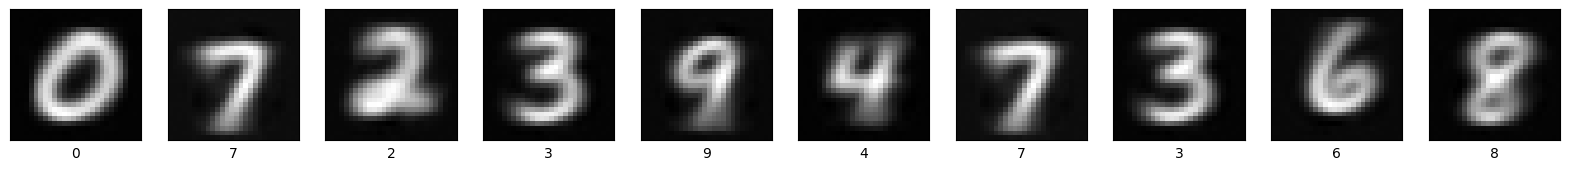

In [5]:
train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS
)

As with bPC, downweighting the forward energy (equivalently upweighting the backward / classification energy) biases the joint objective toward classification. We reproduce this knob below with $\alpha_f = 10^{-3}$.

Iter 50, gen loss=259.919373, amort loss=0.257652, avg amort test accuracy=73.948318
Iter 100, gen loss=258.059601, amort loss=0.264600, avg amort test accuracy=80.358574
Iter 150, gen loss=240.039627, amort loss=0.240329, avg amort test accuracy=81.260017
Iter 200, gen loss=230.172333, amort loss=0.214952, avg amort test accuracy=83.022835
Iter 250, gen loss=241.418304, amort loss=0.268837, avg amort test accuracy=79.096558
Iter 300, gen loss=234.293732, amort loss=0.217228, avg amort test accuracy=80.889420


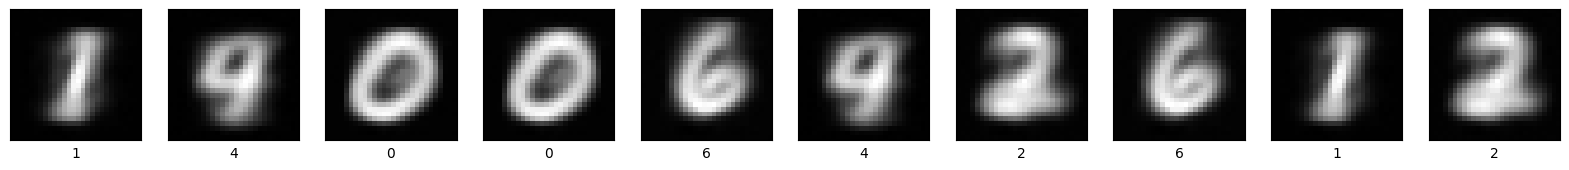

In [6]:
train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    forward_energy_weight=1e-3
)

## Notes and related examples

- bePC reuses [`jpc.init_epc_errors`](https://thebuckleylab.github.io/jpc/api/Initialisation/) for error initialisation. The top-down network uses these errors exactly as in [`epc.ipynb`](./epc.ipynb), while the bottom-up network is trained on the same error-perturbed activities that drive the bPC backward energy in [`bidirectional_pc.ipynb`](./bidirectional_pc.ipynb).
- An incremental variant ("ibePC") is a one-line change: move the `update_bepc_params` call inside the inference loop, analogous to how [`iepc.ipynb`](./iepc.ipynb) relates to [`epc.ipynb`](./epc.ipynb).